# Build and Inspect SFC Fields

`SFCProjection` maps a particle catalogue onto scaling-function coefficients (SFCs). The resulting `SFCField` is the reusable field object consumed by PyHermes windows and correlation tasks.

This notebook starts from the same public Quijote halo catalogue and YAML as `quick_start.ipynb`. It then builds the complete example field set in one top-to-bottom run: the standard and higher-resolution number fields, a halo-mass field, redshift-space fields, and a matching random field. It also reconstructs the represented density field and compares it with direct halo binning. For catalogue formats and conversion, see `particle_io.ipynb`.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize, PowerNorm
import numpy as np
from scipy.ndimage import gaussian_filter

from pyhermes.base import SFCProjection
from pyhermes.io import read_particle_data
from pyhermes.param.parambase import read_param
from pyhermes.utils.redshift_space import hubble_at_redshift, redshift_space_positions
from pyhermes.utils.sampling import random_box_positions

cwd = Path.cwd().resolve()
if cwd.name == "notebooks" and cwd.parent.name == "examples":
    examples_dir = cwd.parent
elif cwd.name == "examples":
    examples_dir = cwd
elif (cwd / "examples").is_dir():
    examples_dir = cwd / "examples"
else:
    raise RuntimeError("Run this notebook from the project root, examples/, or examples/notebooks/.")

os.chdir(examples_dir)
Path("./output").mkdir(exist_ok=True)
Path("./figs").mkdir(exist_ok=True)
print(f"Working directory: {Path.cwd()}")

Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


## 1. Project the configuration-defined catalogue

The YAML is the source of truth for the catalogue URL and cache, box, multiresolution basis, normalization, companion particle data, and output paths. The equivalent command-line run is:

```bash
python scripts/run_sfc_projection.py configs/param_sfc_projection.yaml
```

In [2]:
projection_params = read_param("./configs/param_sfc_projection.yaml")
projection_config = projection_params["SFCProjection"]

projection_task = SFCProjection(projection_params)
field_j8 = projection_task.run(overwrite=True)

12:59:49 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_sfc_projection.yaml'
12:59:49 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
12:59:49 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
12:59:49 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.path' from 'empty' to 'https://pyhermes.astroslacker.com/downloads/quijote_halos_8000_snap004.npz'
12:59:49 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.format' from 'bin' to 'npz'
12:59:49 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.download.cache_path' from 'empty' to './data/quijote_halos_8000_snap004.npz'
12:59:49 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.download.sha256' from 'empty' to 'b2b4b8c2fb91fa857e21b43d943cc32a2c423ee7cf5d7f13dede608264b08ef6'
12:59:49 - INFO - pyhermes.param.parambase:ParamBase - Defaul

In [3]:
print(f"epsilon shape: {field_j8.epsilon.shape}")
print(f"J={field_j8.J}, cells per axis={field_j8.L}, cell spacing={field_j8.box_size / field_j8.L:.3f} Mpc/h")
print(f"field integral: {field_j8.field_integral:.6g}")
print(f"normalization: {field_j8.weight_normalization}")

epsilon shape: (256, 256, 256)
J=8, cells per axis=256, cell spacing=3.906 Mpc/h
field integral: 1
normalization: catalog


## 2. Reuse one catalogue for related fields

Once the source catalogue is in memory, related fields need only a few changed inputs. `catalog_weight` controls how objects contribute statistically, whereas `field_value` is the scalar carried by each object. Unit values produce a number field; halo mass as `field_value` produces a mass field. Increasing `J` doubles the number of scaling cells along each axis.

In [4]:
fin = projection_config["fin"]
halo_data = read_particle_data(
    fin["path"],
    data_format=fin["format"],
    download=fin["download"],
    fields={
        "vel_x": "vel_x",
        "vel_y": "vel_y",
        "vel_z": "vel_z",
        "mass": "mass",
    },
)
pos = halo_data["pos"]
velocity = np.column_stack([halo_data["vel_x"], halo_data["vel_y"], halo_data["vel_z"]])
mass = halo_data["mass"]
print(f"Loaded {halo_data['size']:,} haloes")

12:59:50 - INFO - pyhermes.io.resources:resolve_data_path - Using cached particle data: data/quijote_halos_8000_snap004.npz
12:59:50 - INFO - pyhermes.io.readers:read_particle_data - Selected input particle format: npz
12:59:50 - INFO - pyhermes.io.readers:read_npz - Reading particle data from ---> data/quijote_halos_8000_snap004.npz <---
Loaded 406,728 haloes


In [5]:
def project_arrays(
    particle_pos,
    *,
    field_value=None,
    J=None,
    fout_path="",
    particle_data_path="",
):
    task = SFCProjection()
    task.particle_pos = np.asarray(particle_pos, dtype=np.float32)
    task.field_value = None if field_value is None else np.asarray(field_value, dtype=np.float32)
    task.box_size = projection_config["box_size"]
    task.J = projection_config["J"] if J is None else J
    task.wavelet_mode = projection_config["wavelet_mode"]
    task.wavelet_level = projection_config["wavelet_level"]
    task.phi_resolution = projection_config["phi_resolution"]
    task.weight_normalization = projection_config["weight_normalization"]
    task.threads = projection_config["threads"]
    task.fout_path = fout_path
    task.save_particle_data = bool(particle_data_path)
    task.particle_data_path = particle_data_path
    return task.run(save_result=bool(fout_path), overwrite=True)

In [6]:
field_j9 = project_arrays(
    pos,
    J=9,
    fout_path="./output/quijote8000_snap004_sfc_J9.pkl",
)
mass_field = project_arrays(
    pos,
    field_value=mass,
    fout_path="./output/quijote8000_snap004_sfc_massweight.pkl",
)

print(f"number-field integral: {field_j8.field_integral:.6g}")
print(f"mass-field integral: {mass_field.field_integral:.6e}")
print(f"mean input halo mass: {mass.mean():.6e}")

12:59:50 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
12:59:50 - INFO - pyhermes.pipeline.pipeline:SFCProjection - SFCProjection runtime configuration: running on 1 MPI ranks with 2 threads per rank
12:59:50 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Preparing SFCProjection input fields ...
12:59:50 - INFO - pyhermes.pipeline.pipeline:SFCProjection - J=9, L=512, box_size=1000.0, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
12:59:50 - INFO - pyhermes.pipeline.pipeline:SFCProjection - No catalog_weight provided; using unit catalogue weights for 406728 particles.
12:59:50 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Input particles ready | source=custom particle_pos array | particle_count=406728 | catalog_weight_key=None | field_value_key=None | weight_normalization=catalog | catalog_weight_sum=4.067280e+05 | field_integral=1.000000e+00
12:59:50 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Single process mode
1

## 3. Reconstruct the projected density field

The stored coefficients are expansion coefficients, not density samples. At multiresolution level $j$, PyHermes reconstructs the represented field as

$$
F_j(\mathbf{x}) = \sum_{\boldsymbol{\ell}} \epsilon^j_{\boldsymbol{\ell}}\,\phi^j_{\boldsymbol{\ell}}(\mathbf{x}),
\qquad
\phi^j_{\boldsymbol{\ell}}(\mathbf{x}) = \prod_{d=1}^{3}\phi^j_{\ell_d}(x_d).
$$

For a slab centred on $z_0$ with thickness $\Delta z$, the plotted projected field is

$$
\Sigma_j(x,y) = \int_{z_0-\Delta z/2}^{z_0+\Delta z/2} F_j(x,y,z)\,\mathrm{d}z.
$$

Panels A-C evaluate this expression at $J=7,8,9$. Panel D directly bins the same halo subset in the same slab. All panels use the same catalogue normalization, display smoothing, colormap, and color normalization, so their structures can be compared directly.

In [7]:
field_j7 = project_arrays(pos, J=7)

box_size = float(projection_config["box_size"])
x_range = (300.0, 700.0)
y_range = (300.0, 700.0)
slice_z = 500.0
slice_thickness = 50.0


def periodic_slab_mask(values, center, thickness, period):
    periodic_delta = (values - center + 0.5 * period) % period - 0.5 * period
    return np.abs(periodic_delta) <= 0.5 * thickness


halo_mask = (
    periodic_slab_mask(pos[:, 2], slice_z, slice_thickness, box_size)
    & (pos[:, 0] >= x_range[0])
    & (pos[:, 0] <= x_range[1])
    & (pos[:, 1] >= y_range[0])
    & (pos[:, 1] <= y_range[1])
)
halo_cut = pos[halo_mask]
print(f"Haloes in the displayed slab: {halo_cut.shape[0]:,}")

12:59:53 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
12:59:53 - INFO - pyhermes.pipeline.pipeline:SFCProjection - SFCProjection runtime configuration: running on 1 MPI ranks with 2 threads per rank
12:59:54 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Preparing SFCProjection input fields ...
12:59:54 - INFO - pyhermes.pipeline.pipeline:SFCProjection - J=7, L=128, box_size=1000.0, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
12:59:54 - INFO - pyhermes.pipeline.pipeline:SFCProjection - No catalog_weight provided; using unit catalogue weights for 406728 particles.
12:59:54 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Input particles ready | source=custom particle_pos array | particle_count=406728 | catalog_weight_key=None | field_value_key=None | weight_normalization=catalog | catalog_weight_sum=4.067280e+05 | field_integral=1.000000e+00
12:59:54 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Single process mode
1

In [8]:
def reconstructed_projected_density(field, nx=256, nz=16, chunk_size=262_144):
    x_edges = np.linspace(*x_range, nx + 1)
    y_edges = np.linspace(*y_range, nx + 1)
    x = 0.5 * (x_edges[:-1] + x_edges[1:])
    y = 0.5 * (y_edges[:-1] + y_edges[1:])
    dz = slice_thickness / nz
    z = (slice_z - 0.5 * slice_thickness + (np.arange(nz) + 0.5) * dz) % box_size
    xx, yy = np.meshgrid(x, y, indexing="ij")
    xy = np.column_stack([xx.ravel(), yy.ravel()])
    projected = np.zeros(xx.size, dtype=np.float64)

    for z_value in z:
        sample_pos = np.column_stack([xy, np.full(xy.shape[0], z_value)])
        for start in range(0, sample_pos.shape[0], chunk_size):
            stop = min(start + chunk_size, sample_pos.shape[0])
            projected[start:stop] += (
                field.field_density_at_pos(sample_pos[start:stop], value_unit="physical") * dz
            )

    return projected.reshape(nx, nx)


def halo_projected_density_reference(halo_positions, particle_count, nx=256):
    pixel_area = ((x_range[1] - x_range[0]) / nx) * ((y_range[1] - y_range[0]) / nx)
    weights = np.full(halo_positions.shape[0], 1.0 / particle_count)
    histogram, _, _ = np.histogram2d(
        halo_positions[:, 0],
        halo_positions[:, 1],
        bins=nx,
        range=[x_range, y_range],
        weights=weights,
    )
    return histogram / pixel_area


def smooth_for_display(image, nx, smooth_mpc):
    if smooth_mpc <= 0.0:
        return image
    sigma_pixels = smooth_mpc * nx / (x_range[1] - x_range[0])
    return gaussian_filter(image, sigma=sigma_pixels, mode="nearest")

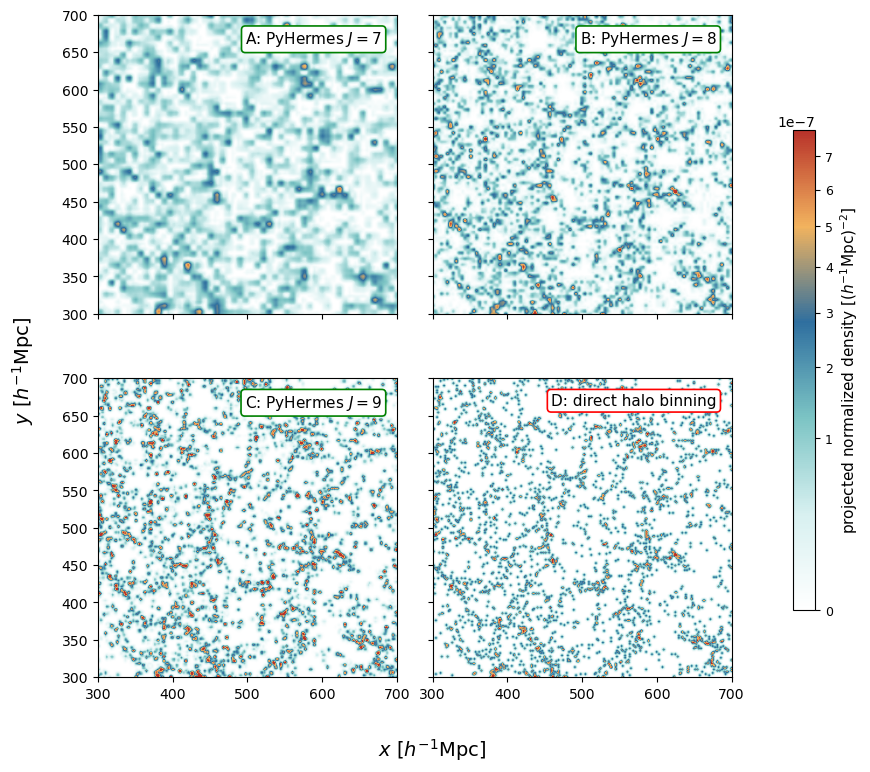

In [9]:
reconstruct_nx = 256
reconstruct_nz = 16
display_smooth_mpc = 1.0
use_power_norm = True
gamma = 0.5

reconstructed_maps = [
    reconstructed_projected_density(field, nx=reconstruct_nx, nz=reconstruct_nz)
    for field in (field_j7, field_j8, field_j9)
]
halo_reference = halo_projected_density_reference(
    halo_cut,
    field_j8.particle_count,
    nx=reconstruct_nx,
)
display_maps = [
    smooth_for_display(np.clip(image, 0.0, None), reconstruct_nx, display_smooth_mpc)
    for image in (*reconstructed_maps, halo_reference)
]

positive_values = np.concatenate([image[image > 0.0] for image in display_maps])
vmax = np.percentile(positive_values, 99.7)
density_norm = (
    PowerNorm(gamma=gamma, vmin=0.0, vmax=vmax)
    if use_power_norm
    else Normalize(vmin=0.0, vmax=vmax)
)
density_cmap = LinearSegmentedColormap.from_list(
    "reconstructed_density",
    ["#ffffff", "#d7f0f0", "#7cc4c4", "#2f6f9f", "#f2b35e", "#b8322a"],
)

fig, axes = plt.subplots(2, 2, figsize=(8.8, 8.0), sharex=True, sharey=True)
extent = (*x_range, *y_range)
panels = [
    (axes[0, 0], display_maps[0], r"A: PyHermes $J=7$", "green"),
    (axes[0, 1], display_maps[1], r"B: PyHermes $J=8$", "green"),
    (axes[1, 0], display_maps[2], r"C: PyHermes $J=9$", "green"),
    (axes[1, 1], display_maps[3], "D: direct halo binning", "red"),
]

for ax, image, label, edgecolor in panels:
    ax.imshow(
        image.T,
        origin="lower",
        extent=extent,
        cmap=density_cmap,
        norm=density_norm,
        interpolation="bilinear",
    )
    ax.text(
        0.95,
        0.95,
        label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor=edgecolor, linewidth=1.2),
    )

for ax in axes.ravel():
    ax.set_xlim(*x_range)
    ax.set_ylim(*y_range)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=10)
    ax.label_outer()

fig.supxlabel(r"$x\ [h^{-1}\mathrm{Mpc}]$", fontsize=14)
fig.supylabel(r"$y\ [h^{-1}\mathrm{Mpc}]$", fontsize=14)
fig.subplots_adjust(left=0.12, right=0.84, bottom=0.10, top=0.96, wspace=0.12, hspace=0.12)

mappable = ScalarMappable(norm=density_norm, cmap=density_cmap)
mappable.set_array([])
colorbar_ax = fig.add_axes([0.91, 0.20, 0.025, 0.60])
colorbar = fig.colorbar(mappable, cax=colorbar_ax)
colorbar.set_label(r"projected normalized density [$(h^{-1}\mathrm{Mpc})^{-2}$]", fontsize=11)
colorbar.ax.tick_params(labelsize=9)

fig.savefig(
    "./figs/sfc_field_reconstructed_density_j7_j8_j9_halo_binned.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 4. Transform coordinates, then project once

Redshift-space distortions enter through particle coordinates. The next cell constructs both the common distant-observer line of sight along `z` and a diagonal line of sight, then projects number and mass fields with the same SFC basis. The shifted particle positions are saved as companion NPZ files for later particle-centred statistics.

In [10]:
redshift = 0.0
hubble = hubble_at_redshift(redshift)
rsd_pos_z = redshift_space_positions(pos, velocity, box_size, hubble, redshift, los="z")
rsd_pos_diag = redshift_space_positions(pos, velocity, box_size, hubble, redshift, los=[1, 1, 1])

rsd_field = project_arrays(
    rsd_pos_z,
    fout_path="./output/quijote8000_snap004_rsd_sfc.pkl",
    particle_data_path="./data/quijote_halos/8000/groups_004/group_tab_004.pos.rsd.npz",
)
rsd_mass_field = project_arrays(
    rsd_pos_z,
    field_value=mass,
    fout_path="./output/quijote8000_snap004_rsd_sfc_massweight.pkl",
    particle_data_path="./data/quijote_halos/8000/groups_004/group_tab_004.pos.rsd_massweight.npz",
)
rsd_diag_field = project_arrays(
    rsd_pos_diag,
    fout_path="./output/quijote8000_snap004_rsd_diag_sfc.pkl",
    particle_data_path="./data/quijote_halos/8000/groups_004/group_tab_004.pos.rsd_diag.npz",
)

12:59:56 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
12:59:56 - INFO - pyhermes.pipeline.pipeline:SFCProjection - SFCProjection runtime configuration: running on 1 MPI ranks with 2 threads per rank
12:59:56 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Preparing SFCProjection input fields ...
12:59:56 - INFO - pyhermes.pipeline.pipeline:SFCProjection - J=8, L=256, box_size=1000.0, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
12:59:56 - INFO - pyhermes.pipeline.pipeline:SFCProjection - No catalog_weight provided; using unit catalogue weights for 406728 particles.
12:59:56 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Input particles ready | source=custom particle_pos array | particle_count=406728 | catalog_weight_key=None | field_value_key=None | weight_normalization=catalog | catalog_weight_sum=4.067280e+05 | field_integral=1.000000e+00
12:59:56 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Saved particle positi

In [11]:
slice_resolution = 160
z_slice = 0.5 * box_size
slice_axis = (np.arange(slice_resolution) + 0.5) * box_size / slice_resolution
slice_x, slice_y = np.meshgrid(slice_axis, slice_axis, indexing="xy")
slice_pos = np.column_stack([
    slice_x.ravel(),
    slice_y.ravel(),
    np.full(slice_x.size, z_slice),
])


def plane_density_contrast(field):
    density = field.field_density_at_pos(slice_pos, value_unit="physical")
    mean_density = field.field_mean_density(value_unit="physical")
    return (density / mean_density - 1.0).reshape(slice_x.shape)


delta_real = plane_density_contrast(field_j8)
delta_rsd = plane_density_contrast(rsd_field)

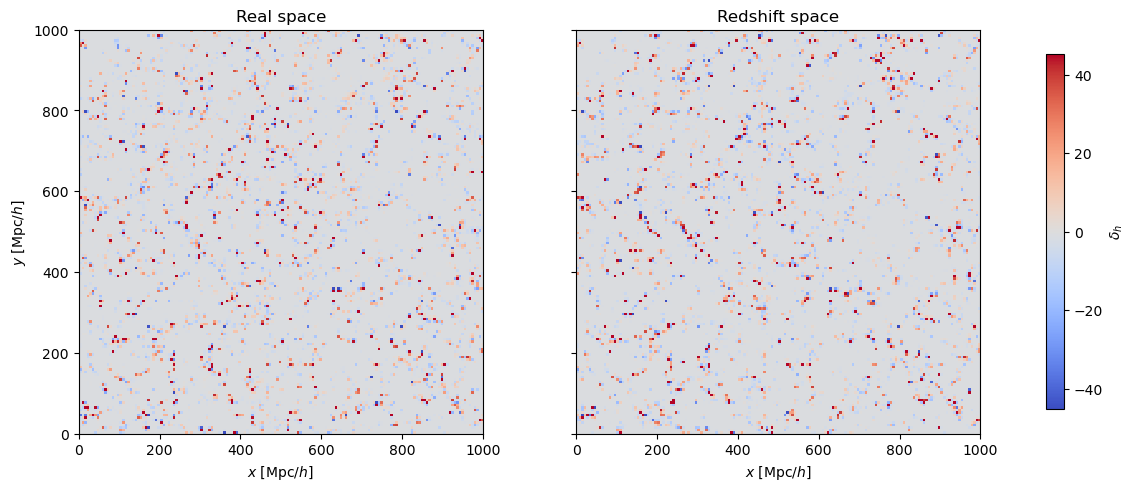

In [12]:
vmax = np.percentile(np.abs(np.concatenate([delta_real.ravel(), delta_rsd.ravel()])), 99.0)
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8), sharex=True, sharey=True, constrained_layout=True)

for ax, delta, title in zip(axes, [delta_real, delta_rsd], ["Real space", "Redshift space"]):
    image = ax.imshow(
        delta,
        origin="lower",
        extent=(0.0, box_size, 0.0, box_size),
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax,
        interpolation="nearest",
    )
    ax.set_title(title)
    ax.set_xlabel(r"$x$ [Mpc/$h$]")

axes[0].set_ylabel(r"$y$ [Mpc/$h$]")
fig.colorbar(image, ax=axes, label=r"$\delta_h$", shrink=0.88)
fig.savefig("./figs/sfc_projection_real_rsd_slice.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Build the matching random field

Correlation estimators need a random catalogue with the same selection function as the data. For this periodic-box example, the selection is uniform. The fixed seed makes the 10-million-point random field exactly reproducible, and its companion NPZ stores the generated positions.

In [13]:
random_count = 10_000_000
random_pos = random_box_positions(count=random_count, box_size=box_size, seed=42).astype(
    np.float32,
    copy=False,
)
random_field = project_arrays(
    random_pos,
    fout_path="./output/random_sfc.pkl",
    particle_data_path="./data/random_1e7.npz",
)
del random_pos

12:59:58 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
12:59:58 - INFO - pyhermes.pipeline.pipeline:SFCProjection - SFCProjection runtime configuration: running on 1 MPI ranks with 2 threads per rank
12:59:58 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Preparing SFCProjection input fields ...
12:59:58 - INFO - pyhermes.pipeline.pipeline:SFCProjection - J=8, L=256, box_size=1000.0, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
12:59:58 - INFO - pyhermes.pipeline.pipeline:SFCProjection - No catalog_weight provided; using unit catalogue weights for 10000000 particles.
12:59:58 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Input particles ready | source=custom particle_pos array | particle_count=10000000 | catalog_weight_key=None | field_value_key=None | weight_normalization=catalog | catalog_weight_sum=1.000000e+07 | field_integral=1.000000e+00
12:59:58 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Saved particle po

## 6. Inspect the companion data and generated products

When `save_particle_data: true`, `SFCProjection` writes the exact positions and scalar factors used by that projection. This compact companion lets particle-centred statistics recover their catalogue consistently. It is intentionally different from the richer public source NPZ, which also stores velocities, mass, and particle count.

In [14]:
particle_data = field_j8.get_particle_data()
print(f"companion arrays: {sorted(particle_data)}")
print(f"positions: {particle_data['pos'].shape}")
print(f"projection-weight sum: {particle_data['projection_weight'].sum():.6g}")

companion arrays: ['catalog_weight', 'field_value', 'normalized_catalog_weight', 'pos', 'projection_weight']
positions: (406728, 3)
projection-weight sum: 1


In [15]:
generated_products = [
    "./output/quijote8000_snap004_sfc.pkl",
    "./output/quijote8000_snap004_particles.npz",
    "./output/quijote8000_snap004_sfc_J9.pkl",
    "./output/quijote8000_snap004_sfc_massweight.pkl",
    "./output/quijote8000_snap004_rsd_sfc.pkl",
    "./output/quijote8000_snap004_rsd_sfc_massweight.pkl",
    "./output/quijote8000_snap004_rsd_diag_sfc.pkl",
    "./output/random_sfc.pkl",
    "./data/quijote_halos/8000/groups_004/group_tab_004.pos.rsd.npz",
    "./data/quijote_halos/8000/groups_004/group_tab_004.pos.rsd_massweight.npz",
    "./data/quijote_halos/8000/groups_004/group_tab_004.pos.rsd_diag.npz",
    "./data/random_1e7.npz",
]

for product in generated_products:
    path = Path(product)
    print(f"{path}: {path.stat().st_size / 1024**2:.1f} MiB")

output/quijote8000_snap004_sfc.pkl: 128.0 MiB
output/quijote8000_snap004_particles.npz: 10.9 MiB
output/quijote8000_snap004_sfc_J9.pkl: 1024.0 MiB
output/quijote8000_snap004_sfc_massweight.pkl: 128.0 MiB
output/quijote8000_snap004_rsd_sfc.pkl: 128.0 MiB
output/quijote8000_snap004_rsd_sfc_massweight.pkl: 128.0 MiB
output/quijote8000_snap004_rsd_diag_sfc.pkl: 128.0 MiB
output/random_sfc.pkl: 128.0 MiB
data/quijote_halos/8000/groups_004/group_tab_004.pos.rsd.npz: 10.9 MiB
data/quijote_halos/8000/groups_004/group_tab_004.pos.rsd_massweight.npz: 10.9 MiB
data/quijote_halos/8000/groups_004/group_tab_004.pos.rsd_diag.npz: 10.9 MiB
data/random_1e7.npz: 267.0 MiB


## Next steps

This notebook has generated the same reusable example fields as `scripts/prepare_sfc_fields.py`; running that script again is unnecessary. Continue with `window.ipynb`, `counting.ipynb`, and the correlation notebooks to operate on these fields. The script remains useful as a non-interactive batch entry point.